## Ejercicio 3 - Diagrama de Fase Sistema Dinámico Discreto en R²

Sistema lineal discreto:

$$x_{n+1} = A\, x_n, \qquad A = \begin{pmatrix} 0{,}8 & 0{,}5 \\ 0{,}4 & -0{,}7 \end{pmatrix}$$

Las trayectorias son **secuencias de puntos** $\{x_0, A x_0, A^2 x_0, \dots\}$.

In [1]:
import matplotlib.pyplot as plt
import numpy as np

In [2]:
A = np.array([[0.8,  0.5],
              [0.4, -0.7]])
A

array([[ 0.8,  0.5],
       [ 0.4, -0.7]])

In [4]:
#Autovalores y autovectores
vals, vecs = np.linalg.eig(A)
print("Autovalores:", vals)
print("Autovectores:\n", vecs)
vecs_norm = vecs / vecs[0, :] #normalizo autotev

Autovalores: [ 0.92321246 -0.82321246]
Autovectores:
 [[ 0.97095376 -0.29438166]
 [ 0.2392672   0.95568794]]


In [5]:
#cumple mismo rol que odeint en continuo
def iterar(A, x0, N):
    xs = np.zeros((N + 1, 2))
    xs[0] = x0
    for n in range(N):
        xs[n + 1] = A @ xs[n]
    return xs

In [12]:
ic = np.linspace(-10, 10, 5)
ic

array([-10.,  -5.,   0.,   5.,  10.])

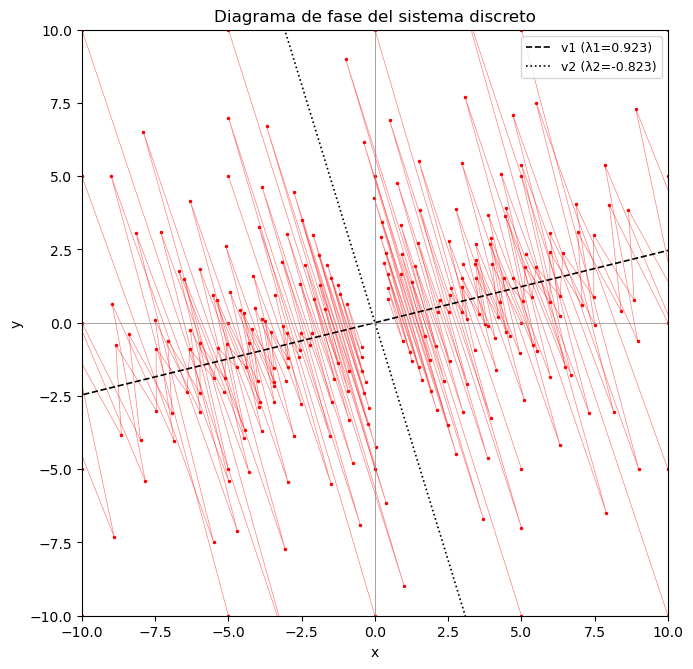

In [13]:
N = 10  # cantidad de iteraciones por trayectoria

fig, ax = plt.subplots(figsize=(7, 7))

for r in ic:
    for s in ic:
        if r == 0 and s == 0:
            continue  # el origen es punto fijo, no aporta
        x0 = np.array([r, s])
        xs = iterar(A, x0, N)
        ax.plot(xs[:, 0], xs[:, 1], 'r-', lw=0.5, alpha=0.5)
        ax.plot(xs[:, 0], xs[:, 1], 'r.', ms=3)

t_line = np.linspace(-12, 12, 2)
v1 = vecs_norm[:, 0].real
v2 = vecs_norm[:, 1].real
ax.plot(t_line * v1[0], t_line * v1[1], 'k--', lw=1.2, label=f'v1 (λ1={vals[0].real:.3f})')
ax.plot(t_line * v2[0], t_line * v2[1], 'k:',  lw=1.2, label=f'v2 (λ2={vals[1].real:.3f})')

ax.set_xlim(-10, 10)
ax.set_ylim(-10, 10)
ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title('Diagrama de fase del sistema discreto')
ax.axhline(0, color='gray', lw=0.5)
ax.axvline(0, color='gray', lw=0.5)
ax.legend(loc='upper right', fontsize=9)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()